# 04 Analyse en composantes principales

Nous avons choisi notre cible dans le notebook 02 et préparé les entrées dans le notebook 03. Nous réalisons maintenant une **ACP**, comme demandé dans le sujet et étudié dans le CM 2 et le TD 2.

L’ACP remplace les variables d’origine par de nouvelles variables, appelées **composantes principales** ou **axes**. Chaque axe combine plusieurs entrées. Les premiers axes résument les directions où les observations varient le plus.

Nous cherchons à répondre à trois questions : combien d’axes faut-il pour résumer les données ? Quelles variables sont liées aux premiers axes ? Que voit-on quand on représente les observations sur deux axes ?

Nous utilisons seulement le développement. L’ACP est construite à partir de X, sans utiliser notre score y pour choisir les axes. Nous n’entraînons pas encore de modèle.

## 1 Charger les données préparées

Nous reprenons le tableau préparé par le notebook 03. Il contient 539 lignes et 36 colonnes numériques après encodage.

Pour cette première ACP, nous gardons uniquement les **22 variables numériques d’origine**, déjà imputées et standardisées. Les colonnes issues des trois variables catégorielles restent disponibles pour les modèles, mais ne participent pas à cette analyse. Nous privilégions ainsi une interprétation simple de la composition et des paramètres numériques du soudage.

Ce choix est une restriction de l’analyse, pas une nouvelle suppression de variables dans tout le projet.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.decomposition import PCA

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
OUT = ROOT / 'outputs/04'
OUT.mkdir(parents=True, exist_ok=True)

X_prepare = pd.read_csv(ROOT / 'outputs/03/X_developpement_prepare.csv',
                        index_col='row_id', float_precision='round_trip')
choix = json.loads((ROOT / 'outputs/03/choix_preparation.json').read_text())
assert X_prepare.index.tolist() == choix['dev_row_ids']
assert X_prepare.columns.tolist() == choix['colonnes_preparees']

X_acp = X_prepare.filter(regex='^nombres__').copy()
X_acp.columns = X_acp.columns.str.replace('nombres__', '', regex=False)
assert X_acp.shape[1] > 1
print(f'ACP sur {len(X_acp)} lignes et {X_acp.shape[1]} variables numériques.')
display(X_acp.head().round(3))

ACP sur 539 lignes et 22 variables numériques.


,C,Si,Mn,S,P,Ni,Cr,Mo,V,Cu,O_ppm,Ti_ppm,N_ppm,Al_ppm,B_ppm,Nb_ppm,Current_A,Voltage_V,HeatInput_kJmm,InterpassT_C,PWHT_T_C,PWHT_time_h
row_id,,,,,,,,,,,,,,,,,,,,,,
0,-1.689,-0.304,-1.361,-0.223,-0.070,-0.352,-0.338,-0.433,-0.163,-0.228,-0.135,-0.254,-0.252,-0.407,-0.153,-0.346,-0.516,-0.502,-0.589,-0.123,-0.344,1.331
2,-1.689,-0.304,-1.361,-0.223,-0.070,-0.352,-0.338,-0.433,-0.163,-0.228,-0.135,-0.254,-0.252,-0.407,-0.153,-0.346,-0.516,-0.502,-0.589,-0.123,0.992,-0.637
3,-1.689,-0.231,-0.393,-0.355,0.091,-0.352,-0.338,-0.433,-0.163,-0.228,-0.135,-0.254,-0.252,-0.407,-0.153,-0.346,-0.516,-0.502,-0.589,-0.123,-0.344,1.331
5,-1.689,-0.231,-0.393,-0.355,0.091,-0.352,-0.338,-0.433,-0.163,-0.228,-0.135,-0.254,-0.252,-0.407,-0.153,-0.346,-0.516,-0.502,-0.589,-0.123,0.992,-0.637
12,-1.595,-0.159,-1.336,-0.487,-0.151,0.519,-0.338,-0.433,-0.163,-0.228,-0.135,-0.254,-0.252,-0.407,-0.153,-0.346,-0.516,-0.502,-0.589,-0.123,-0.344,1.331


## 2 Vérifier les échelles

Le carbone est mesuré en pourcentage massique, certains éléments en ppm, la température en degrés et le courant en ampères. Sans standardisation, des variables pourraient dominer l’ACP simplement parce que leurs nombres sont plus grands ou plus dispersés.

Le notebook 03 a déjà centré et réduit les colonnes numériques. Nous vérifions donc que leur moyenne est proche de 0 et leur écart-type proche de 1. Nous ne standardisons pas une deuxième fois.

Cette standardisation ne supprime pas l’influence possible de valeurs extrêmes. Nous avons également remplacé les absences par des médianes : l’ACP décrit donc les données **après cette préparation**, pas seulement les mesures observées.

In [2]:
controle = pd.DataFrame({
    'moyenne': X_acp.mean(),
    'ecart_type': X_acp.std(ddof=0)
})
assert np.isfinite(X_acp.to_numpy()).all()
assert np.allclose(controle['moyenne'], 0, atol=1e-8)
assert np.allclose(controle['ecart_type'], 1, atol=1e-8)
display(controle.round(3))

,moyenne,ecart_type
C,-0.0,1.0
Si,-0.0,1.0
Mn,0.0,1.0
S,-0.0,1.0
P,-0.0,1.0
Ni,0.0,1.0
Cr,-0.0,1.0
Mo,0.0,1.0
V,0.0,1.0
Cu,0.0,1.0


## 3 Calculer l’ACP

Nous calculons d’abord tous les axes, pour voir ce que chacun apporte. `fit_transform` apprend les axes sur le développement puis calcule la position de chaque observation sur ces axes.

Les axes sont appelés PC1, PC2, etc. PC1 explique la plus grande part de variance ; PC2 explique la plus grande part restante, dans une direction perpendiculaire à PC1.

In [3]:
acp = PCA(svd_solver='full')
positions = acp.fit_transform(X_acp)
noms_axes = [f'PC{i+1}' for i in range(acp.n_components_)]
coordonnees = pd.DataFrame(positions, index=X_acp.index, columns=noms_axes)

display(coordonnees.iloc[:5, :4].round(3))

,PC1,PC2,PC3,PC4
row_id,,,,
0,0.601,-1.869,0.910,0.187
2,0.748,-1.325,1.171,0.171
3,0.366,-1.890,0.672,0.185
5,0.513,-1.347,0.933,0.169
12,0.601,-2.004,0.759,0.304


## 4 Voir combien d’axes résument les données

La **variance expliquée** indique la part des différences entre observations représentée par un axe. La variance cumulée additionne les parts des premiers axes.

Nous regardons les seuils de 80 % et de 90 %, comme repères de résumé. Ce ne sont pas des pourcentages de précision du modèle et ils ne garantissent pas une bonne prédiction de y.

In [4]:
variance = pd.DataFrame({
    'variance_expliquee_pct': 100 * acp.explained_variance_ratio_,
    'variance_cumulee_pct': 100 * np.cumsum(acp.explained_variance_ratio_)
}, index=noms_axes)

def nombre_axes(seuil):
    return int(np.searchsorted(variance['variance_cumulee_pct'], seuil) + 1)

n80, n90 = nombre_axes(80), nombre_axes(90)
print(f'Les deux premiers axes expliquent {variance.iloc[1, 1]:.1f} % de la variance.')
print(f'Pour au moins 80 % : {n80} axes. Pour au moins 90 % : {n90} axes.')
display(variance.round(2))

Les deux premiers axes expliquent 33.9 % de la variance.
Pour au moins 80 % : 11 axes. Pour au moins 90 % : 14 axes.


,variance_expliquee_pct,variance_cumulee_pct
PC1,17.93,17.93
PC2,15.95,33.88
PC3,8.59,42.48
PC4,7.02,49.49
PC5,5.91,55.40
PC6,5.35,60.75
PC7,4.39,65.15
PC8,4.16,69.30
PC9,4.05,73.36
PC10,3.76,77.12


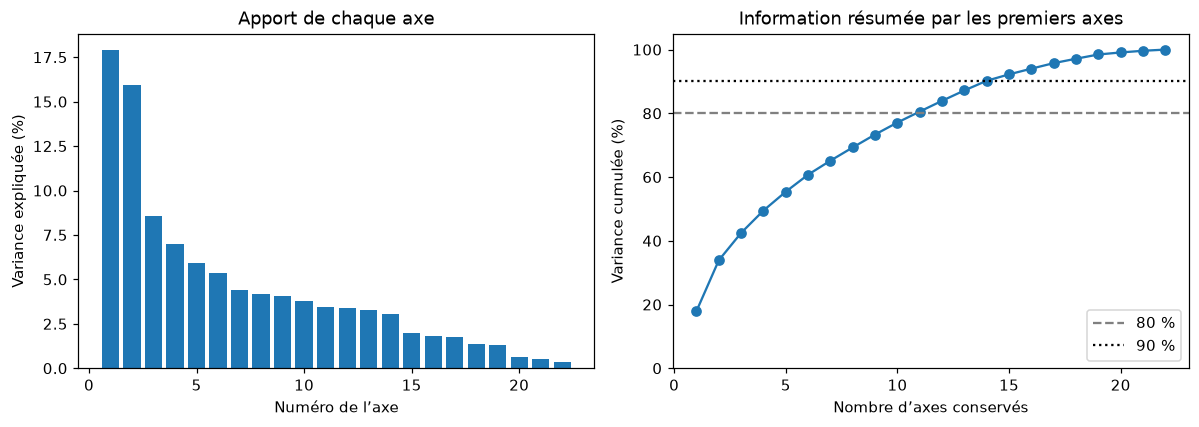

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
numeros = np.arange(1, len(noms_axes) + 1)
axes[0].bar(numeros, variance['variance_expliquee_pct'])
axes[0].set(xlabel='Numéro de l’axe', ylabel='Variance expliquée (%)',
            title='Apport de chaque axe')
axes[1].plot(numeros, variance['variance_cumulee_pct'], marker='o')
axes[1].axhline(80, color='grey', linestyle='--', label='80 %')
axes[1].axhline(90, color='black', linestyle=':', label='90 %')
axes[1].set(xlabel='Nombre d’axes conservés', ylabel='Variance cumulée (%)',
            title='Information résumée par les premiers axes', ylim=(0, 105))
axes[1].legend()
fig.tight_layout()
fig.savefig(OUT / 'variance_expliquee.png', dpi=150)
plt.show()

Nous obtenons environ **33,9 %** avec les deux premiers axes, **80,6 % avec 11 axes** et **90,2 % avec 14 axes**.

La réduction à deux dimensions aide à visualiser les données, mais laisse de côté une grande partie de leur variance. Pour les modèles, nous comparerons l’utilisation d’une ACP à celle des variables préparées sans ACP. Le nombre d’axes devra être choisi par validation, pas sur le test.

## 5 Comprendre les premiers axes

Chaque axe est une combinaison des variables. Le tableau suivant classe les variables selon leur contribution à PC1 et PC2.

La contribution est calculée à partir du carré du coefficient de la variable dans l’axe. Les contributions des 22 variables totalisent 100 % pour chaque axe. Cela indique ce qui construit un axe, **pas l’importance des variables pour prédire la qualité**.

In [6]:
coefficients = pd.DataFrame(acp.components_.T, index=X_acp.columns, columns=noms_axes)
contributions = 100 * coefficients**2
assert np.allclose(contributions.sum(), 100)

for axe in ['PC1', 'PC2']:
    print(f'Les 8 variables qui contribuent le plus à {axe} :')
    display(contributions[axe].sort_values(ascending=False).head(8).round(2).to_frame('contribution_pct'))

Les 8 variables qui contribuent le plus à PC1 :
Les 8 variables qui contribuent le plus à PC2 :


,contribution_pct
Cr,14.13
PWHT_T_C,11.18
N_ppm,10.96
Mo,9.59
Current_A,8.63
HeatInput_kJmm,8.17
Al_ppm,7.13
Si,6.59


,contribution_pct
Voltage_V,13.31
Current_A,12.18
HeatInput_kJmm,11.51
C,8.67
S,8.48
Mo,8.31
Cr,6.77
P,6.38


### Voir quelles variables évoluent ensemble sur ces axes

Nous calculons les corrélations entre chaque variable et les quatre premiers axes. Deux variables de même signe sur un axe évoluent dans le même sens **sur cet axe** ; des signes opposés indiquent des directions opposées. Cela ne suffit pas à décrire toute leur relation dans les 22 dimensions.

Une valeur proche de 0 indique que cet axe représente peu cette variable. Nous ne l’interprétons pas comme une variable inutile pour le modèle.

Le signe global d’un axe est arbitraire : retourner tous ses signes ne change pas l’ACP.

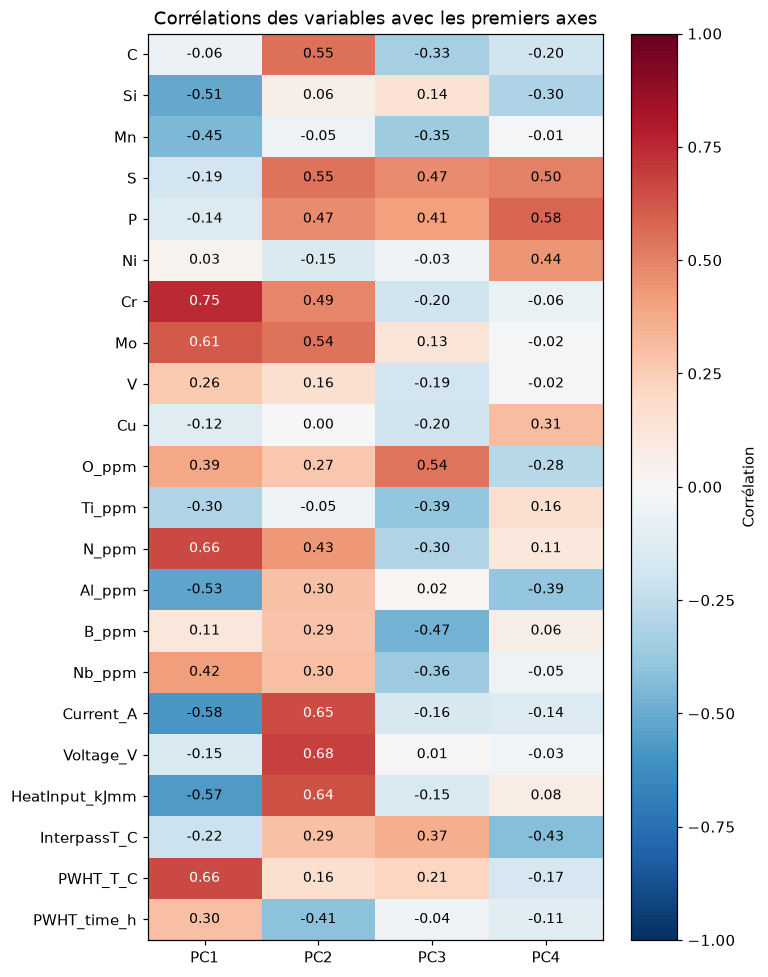

In [7]:
correlations = pd.DataFrame(index=X_acp.columns)
for axe in noms_axes[:4]:
    correlations[axe] = X_acp.corrwith(coordonnees[axe])

fig, ax = plt.subplots(figsize=(7, 9))
image = ax.imshow(correlations, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(4), correlations.columns)
ax.set_yticks(range(len(X_acp.columns)), X_acp.columns)
for ligne in range(len(correlations)):
    for colonne in range(4):
        valeur = correlations.iloc[ligne, colonne]
        ax.text(colonne, ligne, f'{valeur:.2f}', ha='center', va='center',
                color='white' if abs(valeur) > 0.6 else 'black', fontsize=9)
ax.set_title('Corrélations des variables avec les premiers axes')
fig.colorbar(image, ax=ax, label='Corrélation')
fig.tight_layout()
fig.savefig(OUT / 'variables_axes.png', dpi=150)
plt.show()

### Ce que nous observons ici

Sur PC1, le chrome, la température de traitement thermique, l’azote et le molybdène sont du même côté de l’axe. Le courant et l’apport thermique sont de l’autre côté. PC1 distingue donc des variations de composition et de procédé dans les données préparées.

Sur PC2, la tension, le courant et l’apport thermique ont les contributions les plus fortes et vont dans le même sens. Cet axe est notamment lié aux conditions de soudage, tout en dépendant aussi de la composition.

Ce sont des descriptions de notre corpus. Elles ne permettent pas de dire qu’augmenter une de ces variables améliore la qualité.


## 6 Représenter les observations sur deux axes

Chaque point correspond à une ligne d’essai. Nous colorons les points avec le score du notebook 02, **après avoir calculé l’ACP sans ce score**. La couleur sert seulement à explorer une éventuelle organisation du compromis résistance–ductilité.

Deux points proches sont proches dans cette projection. Ils peuvent encore différer sur les axes que nous ne montrons pas. Une séparation visible ne prouve pas une relation causale ni une bonne performance prédictive.

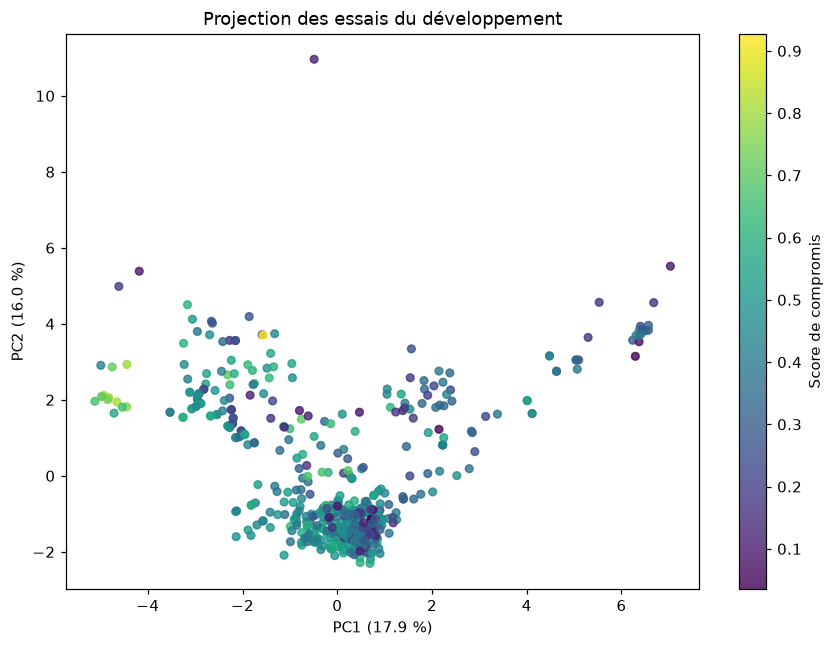

In [8]:
donnees = pd.read_csv(ROOT / 'outputs/02/dataset_traction.csv',
                      index_col='row_id', float_precision='round_trip')
assert donnees.loc[X_acp.index, 'partition'].eq('developpement').all()
score = donnees.loc[X_acp.index, 'score_compromis']

fig, ax = plt.subplots(figsize=(8, 6))
points = ax.scatter(coordonnees['PC1'], coordonnees['PC2'], c=score,
                    cmap='viridis', s=25, alpha=0.8)
ax.set_xlabel(f'PC1 ({variance.iloc[0, 0]:.1f} %)')
ax.set_ylabel(f'PC2 ({variance.iloc[1, 0]:.1f} %)')
ax.set_title('Projection des essais du développement')
fig.colorbar(points, ax=ax, label='Score de compromis')
fig.tight_layout()
fig.savefig(OUT / 'projection_essais.png', dpi=150)
plt.show()

Les couleurs se mélangent dans une grande partie du graphique : ces deux axes ne donnent pas une séparation nette entre scores faibles et élevés. Cela ne signifie pas que les autres entrées ou les autres axes sont inutiles pour la prédiction.

Quelques points sont éloignés du nuage principal. Ce sont des observations à examiner ; nous ne les supprimons pas uniquement parce qu’elles sont éloignées. Leur position peut refléter des conditions réelles particulières ou une erreur à vérifier.


## 7 Garder les résultats pour le rapport

Nous enregistrons les variances, les positions sur les axes, les contributions des variables et les corrélations. Les figures peuvent illustrer le rapport.

Ces coordonnées sont destinées à l’exploration. Pour la validation croisée des modèles, il faudra repartir des entrées non préparées, puis ajuster la préparation **et l’ACP dans chaque apprentissage**. Le test devra être transformé avec les axes appris sur le développement, sans nouvel ajustement.

In [9]:
variance.to_csv(OUT / 'variance_expliquee.csv', index_label='axe')
coordonnees.to_csv(OUT / 'coordonnees_developpement.csv', index_label='row_id')
contributions.to_csv(OUT / 'contributions_variables.csv', index_label='variable')
correlations.to_csv(OUT / 'correlations_variables_axes.csv', index_label='variable')
resume = {
    'variables': X_acp.columns.tolist(),
    'lignes_developpement': X_acp.index.tolist(),
    'variance_deux_axes_pct': float(variance.iloc[1, 1]),
    'axes_pour_80_pct': n80, 'axes_pour_90_pct': n90,
    'usage': 'exploration seulement ; réajuster préparation et ACP dans chaque pli pour les modèles'
}
(OUT / 'resume_acp.json').write_text(json.dumps(resume, ensure_ascii=False, indent=2))
print('Résultats enregistrés dans', OUT)

Résultats enregistrés dans /Users/Marie/Documents/projet-soudures/outputs/04


## Conclusion

Nous avons réalisé une ACP sur les **22 entrées numériques** préparées et les **539 lignes de développement**. La cible et les catégories ne participent pas au calcul des axes.

Les deux premiers axes expliquent environ **34 % de la variance**. Leur graphique donne une vue partielle des observations. Il faut **11 axes pour dépasser 80 %** et **14 pour dépasser 90 %** : deux axes ne suffisent donc pas à résumer l’ensemble des données.

Les contributions et les corrélations permettent de décrire les variables liées à chaque axe. Elles ne démontrent pas quelles variables produisent une meilleure soudure. Nous les utiliserons pour interpréter les données, puis nous examinerons les modèles pour la prédiction.

L’analyse dépend de l’imputation par médiane et du seuil de sélection du notebook 03. Les répétitions d’un dépôt comptent aussi plusieurs fois dans cette ACP, qui donne ici le même poids à chaque ligne. Cette lecture doit donc rester exploratoire.

La prochaine étape sera la comparaison des modèles : commencer par une régression linéaire, un arbre et une forêt aléatoire, puis comparer les préparations et l’intérêt éventuel d’une ACP. Nous garderons les groupes séparés et le test réservé. La partie semi-supervisée demandée par le sujet viendra ensuite.

Références : CM 2 de Myriam Tami et TD 2, sections sur l’ACP et la variance expliquée.